# Day 1 Exercise - Instructor Full Pipeline

This notebook contains the complete runnable pipeline:

1. Collect taxi availability data.
2. Collect 2-hour weather forecast data.
3. Save raw files.
4. Clean and transform data.
5. Spatially aggregate taxi points into planning areas.
6. Merge taxi and weather data.
7. Store dashboard-ready data in DuckDB.

The final database is `shared_data/day_1_weather_taxi_data.duckdb`, which is used by `serving_api.py`.


## 1. Imports and Configuration


In [3]:
#%pip install matplotlib

In [ ]:
from __future__ import annotations

import hashlib
import json
import os
import duckdb
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Any

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

SINGAPORE_TZ = timezone(timedelta(hours=8))

TAXI_API_URL = "https://api.data.gov.sg/v1/transport/taxi-availability"
WEATHER_API_URL = "https://api-open.data.gov.sg/v2/real-time/api/two-hr-forecast"
RAINFALL_API_URL = "https://api-open.data.gov.sg/v2/real-time/api/rainfall"

def find_day1_base_dir() -> Path:
    current = Path.cwd().resolve()
    if (current / "day_1.pptx").exists() or (current / "MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson").exists():
        return current
    for parent in current.parents:
        if parent.name == "day_1" or (parent / "day_1.pptx").exists():
            return parent
    return current


BASE_DIR = find_day1_base_dir()
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
SHARED_DATA_DIR = BASE_DIR / "shared_data"
SHARED_ASSETS_DIR = BASE_DIR / "shared_assets"
DB_PATH = SHARED_DATA_DIR / "day_1_weather_taxi_data.duckdb"
GEOJSON_PATH = SHARED_ASSETS_DIR / "MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson"
API_KEY_PATH = SHARED_ASSETS_DIR / "api_key.txt"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SHARED_DATA_DIR.mkdir(parents=True, exist_ok=True)

REQUEST_TIMEOUT_SECONDS = 30
INCLUDE_ZERO_TAXI_AREAS = False


## 2. Helper Functions


In [5]:
def now_sgt() -> datetime:
    return datetime.now(SINGAPORE_TZ)


def parse_api_timestamp(value: str) -> datetime:
    if not value:
        raise ValueError("Timestamp value is empty")
    parsed = datetime.fromisoformat(value.replace("Z", "+00:00"))
    if parsed.tzinfo is None:
        parsed = parsed.replace(tzinfo=SINGAPORE_TZ)
    return parsed.astimezone(SINGAPORE_TZ)


def to_iso(dt: datetime) -> str:
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=SINGAPORE_TZ)
    return dt.astimezone(SINGAPORE_TZ).isoformat(timespec="seconds")


def payload_hash(payload: Any) -> str:
    encoded = json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def read_api_key() -> str | None:
    env_key = os.getenv("DATA_GOV_API_KEY")
    if env_key:
        return env_key.strip()
    if API_KEY_PATH.exists():
        for line in API_KEY_PATH.read_text(encoding="utf-8").splitlines():
            key = line.strip()
            if key:
                return key
    return None


def request_headers() -> dict[str, str]:
    api_key = read_api_key()
    return {"X-API-Key": api_key} if api_key else {}


def fetch_json(url: str) -> dict[str, Any]:
    response = requests.get(url, headers=request_headers(), timeout=REQUEST_TIMEOUT_SECONDS)
    response.raise_for_status()
    return response.json()


def save_raw_payload_csv(payload: dict[str, Any], path: Path) -> None:
    pd.json_normalize(payload, sep="_").to_csv(path, index=False)


def snapshot_name(prefix: str, collected_at: datetime) -> str:
    return f"{prefix}_{collected_at.strftime('%Y%m%d_%H%M%S')}.csv"


## 3. Collect Taxi and Weather Data


In [12]:
collection_started_at = now_sgt()

taxi_payload = fetch_json(TAXI_API_URL)
weather_payload = fetch_json(WEATHER_API_URL)
rainfall_payload = fetch_json(RAINFALL_API_URL)

taxi_hash = payload_hash(taxi_payload)
weather_hash = payload_hash(weather_payload)
rainfall_hash = payload_hash(rainfall_payload)

taxi_raw_path = RAW_DIR / snapshot_name("taxi_availability", collection_started_at)
weather_raw_path = RAW_DIR / snapshot_name("weather_forecast", collection_started_at)
rainfall_raw_path = RAW_DIR / snapshot_name("rainfall", collection_started_at)

save_raw_payload_csv(taxi_payload, taxi_raw_path)
save_raw_payload_csv(weather_payload, weather_raw_path)
save_raw_payload_csv(rainfall_payload, rainfall_raw_path)

print(f"Saved taxi raw file: {taxi_raw_path}")
print(f"Saved weather raw file: {weather_raw_path}")
print(f"Saved rainfall raw file: {rainfall_raw_path}")
print("Taxi metadata:")
print(json.dumps(taxi_payload.get("features", [{}])[0].get("properties", {}), indent=2))
print("Weather payload keys:")
print(list(weather_payload.get("data", weather_payload).keys()))
print("Rainfall payload keys:")
print(list(rainfall_payload.get("data", rainfall_payload).keys()))


Saved taxi raw file: d:\SIT OneDrive\OneDrive - Singapore Institute Of Technology\project_IMDA\teaching\slides\day_1\data\raw\taxi_availability_20260529_210930.csv
Saved weather raw file: d:\SIT OneDrive\OneDrive - Singapore Institute Of Technology\project_IMDA\teaching\slides\day_1\data\raw\weather_forecast_20260529_210930.csv
Taxi metadata:
{
  "timestamp": "2026-05-29T21:08:41+08:00",
  "taxi_count": 2979,
  "api_info": {
    "status": "healthy"
  }
}
Weather valid period:
{
  "start": "2026-05-29T21:00:00+08:00",
  "end": "2026-05-29T23:00:00+08:00"
}


## 4. Clean Taxi Data


In [7]:
def extract_taxi_coordinates(payload: dict[str, Any]) -> tuple[str, pd.DataFrame]:
    features = payload.get("features", [])
    if not features:
        raise ValueError("Taxi payload has no features")

    first_feature = features[0]
    api_timestamp = first_feature.get("properties", {}).get("timestamp")
    coordinates = first_feature.get("geometry", {}).get("coordinates", [])
    if not api_timestamp:
        raise ValueError("Taxi payload has no properties.timestamp")

    taxi_df = pd.DataFrame(coordinates, columns=["longitude", "latitude"])
    taxi_df["longitude"] = pd.to_numeric(taxi_df["longitude"], errors="coerce")
    taxi_df["latitude"] = pd.to_numeric(taxi_df["latitude"], errors="coerce")
    taxi_df = taxi_df.dropna(subset=["longitude", "latitude"]).reset_index(drop=True)
    return to_iso(parse_api_timestamp(api_timestamp)), taxi_df


taxi_api_timestamp, taxi_points_df = extract_taxi_coordinates(taxi_payload)
taxi_points_path = PROCESSED_DIR / "taxi_points_latest.csv"
taxi_points_df.to_csv(taxi_points_path, index=False)

print(f"Taxi API timestamp: {taxi_api_timestamp}")
print(f"Clean taxi points: {len(taxi_points_df):,}")
display(taxi_points_df.head())


Taxi API timestamp: 2026-05-29T21:04:11+08:00
Clean taxi points: 3,324


,longitude,latitude
0,103.63916,1.29814
1,103.63917,1.29816
2,103.64465,1.32494
3,103.64793,1.32190
4,103.66341,1.31243


## 5. Clean Weather Data


In [11]:
def extract_weather_forecasts(payload: dict[str, Any]) -> pd.DataFrame:
    data = payload.get("data", payload)
    records = data.get("records") or data.get("items") or []
    if not records:
        raise ValueError("Weather payload has no records")

    first_item = records[0]
    update_timestamp = (
        first_item.get("updatedTimestamp")
        or first_item.get("update_timestamp")
        or first_item.get("timestamp")
        or first_item.get("date")
    )
    valid_period = first_item.get("validPeriod") or first_item.get("valid_period") or {}
    valid_period_start = (
        valid_period.get("start")
        or first_item.get("validPeriodStart")
        or first_item.get("timestamp")
        or first_item.get("date")
    )
    valid_period_end = valid_period.get("end") or first_item.get("validPeriodEnd")
    if not update_timestamp or not valid_period_start or not valid_period_end:
        raise ValueError("Weather payload is missing update or valid-period timestamps")

    rows = []
    for forecast_item in first_item.get("forecasts", []):
        area = forecast_item.get("area")
        forecast = forecast_item.get("forecast")
        if area and forecast:
            rows.append({
                "api_update_timestamp": to_iso(parse_api_timestamp(update_timestamp)),
                "valid_period_start": to_iso(parse_api_timestamp(valid_period_start)),
                "valid_period_end": to_iso(parse_api_timestamp(valid_period_end)),
                "area": str(area).strip(),
                "forecast": str(forecast).strip(),
            })
    return pd.DataFrame(rows)


weather_df = extract_weather_forecasts(weather_payload)
weather_path = PROCESSED_DIR / "weather_forecasts_latest.csv"
weather_df.to_csv(weather_path, index=False)

print(f"Weather rows: {len(weather_df):,}")
display(weather_df.head())


Weather rows: 47


,api_update_timestamp,valid_period_start,valid_period_end,area,forecast
0,2026-05-29T20:36:33+08:00,2026-05-29T20:30:00+08:00,2026-05-29T22:30:00+08:00,Ang Mo Kio,Cloudy
1,2026-05-29T20:36:33+08:00,2026-05-29T20:30:00+08:00,2026-05-29T22:30:00+08:00,Bedok,Cloudy
2,2026-05-29T20:36:33+08:00,2026-05-29T20:30:00+08:00,2026-05-29T22:30:00+08:00,Bishan,Cloudy
3,2026-05-29T20:36:33+08:00,2026-05-29T20:30:00+08:00,2026-05-29T22:30:00+08:00,Boon Lay,Cloudy
4,2026-05-29T20:36:33+08:00,2026-05-29T20:30:00+08:00,2026-05-29T22:30:00+08:00,Bukit Batok,Cloudy


## 5B. Clean Current Rainfall Observations

The v2 rainfall API is a current weather observation source. It reports station-level rainfall readings, so its spatial grain is different from the area-level 2-hour forecast.


In [ ]:
def extract_rainfall_readings(payload: dict[str, Any]) -> pd.DataFrame:
    data = payload.get("data", payload)
    stations = data.get("stations") or []
    station_lookup = {
        str(station.get("id") or station.get("deviceId")): station
        for station in stations
        if station.get("id") or station.get("deviceId")
    }
    records = data.get("readings") or data.get("items") or []
    if not records:
        raise ValueError("Rainfall payload has no readings")

    rows = []
    for record in records:
        timestamp = record.get("timestamp") or record.get("date") or record.get("updatedTimestamp")
        readings = record.get("data") or record.get("readings") or []
        for reading in readings:
            station_id = str(reading.get("stationId") or reading.get("station_id") or reading.get("station") or "")
            value = reading.get("value")
            if not station_id or value is None:
                continue
            station = station_lookup.get(station_id, {})
            location = station.get("location") or {}
            rows.append({
                "reading_timestamp": to_iso(parse_api_timestamp(timestamp)),
                "station_id": station_id,
                "station_name": station.get("name"),
                "latitude": location.get("latitude"),
                "longitude": location.get("longitude"),
                "rainfall_mm": float(value),
            })
    return pd.DataFrame(rows)


rainfall_df = extract_rainfall_readings(rainfall_payload)
rainfall_path = PROCESSED_DIR / "rainfall_readings_latest.csv"
rainfall_df.to_csv(rainfall_path, index=False)

print(f"Rainfall rows: {len(rainfall_df):,}")
display(rainfall_df.sort_values("rainfall_mm", ascending=False).head())


## 6. Transform Taxi Points into Planning-Area Counts


In [9]:
def load_subzones(path: Path) -> gpd.GeoDataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Subzone GeoJSON not found: {path}")

    subzones = gpd.read_file(path)
    if "PLN_AREA_N" not in subzones.columns:
        raise ValueError("GeoJSON must contain a PLN_AREA_N column")

    if subzones.crs is None:
        subzones = subzones.set_crs("EPSG:4326")
    else:
        subzones = subzones.to_crs("EPSG:4326")

    subzones = subzones[["PLN_AREA_N", "geometry"]].copy()
    subzones["PLN_AREA_N"] = subzones["PLN_AREA_N"].astype(str).str.strip().str.upper()
    return subzones


def aggregate_taxis_by_planning_area(
    taxi_df: pd.DataFrame,
    subzones: gpd.GeoDataFrame,
    include_zero_areas: bool = False,
) -> tuple[gpd.GeoDataFrame, pd.DataFrame]:
    taxi_points = gpd.GeoDataFrame(
        taxi_df.copy(),
        geometry=gpd.points_from_xy(taxi_df["longitude"], taxi_df["latitude"]),
        crs="EPSG:4326",
    )
    joined = gpd.sjoin(taxi_points, subzones, how="inner", predicate="intersects")
    counts = (
        joined.groupby("PLN_AREA_N")
        .size()
        .rename("available_taxi_count")
        .reset_index()
        .rename(columns={"PLN_AREA_N": "planning_area"})
    )

    if include_zero_areas:
        all_areas = pd.DataFrame({"planning_area": sorted(subzones["PLN_AREA_N"].unique())})
        counts = all_areas.merge(counts, on="planning_area", how="left")
        counts["available_taxi_count"] = counts["available_taxi_count"].fillna(0).astype(int)

    counts["available_taxi_count"] = counts["available_taxi_count"].astype(int)
    counts = counts.sort_values("planning_area").reset_index(drop=True)
    return joined, counts


subzones_gdf = load_subzones(GEOJSON_PATH)
taxis_joined_gdf, taxi_counts_df = aggregate_taxis_by_planning_area(
    taxi_points_df,
    subzones_gdf,
    include_zero_areas=INCLUDE_ZERO_TAXI_AREAS,
)

taxi_counts_path = PROCESSED_DIR / "taxi_counts_by_planning_area_latest.csv"
taxi_counts_df.to_csv(taxi_counts_path, index=False)

print(f"Joined taxi points: {len(taxis_joined_gdf):,}")
print(f"Planning areas with taxis: {len(taxi_counts_df):,}")
display(taxi_counts_df.sort_values("available_taxi_count", ascending=False).head(10))


Joined taxi points: 3,324
Planning areas with taxis: 53


,planning_area,available_taxi_count
9,CHANGI,537
13,DOWNTOWN CORE,399
1,BEDOK,129
5,BUKIT MERAH,125
44,TAMPINES,122
51,WOODLANDS,111
52,YISHUN,107
14,GEYLANG,106
18,KALLANG,104
15,HOUGANG,100


## 6B. Visual Check: Taxi Points on Singapore Boundaries

A spatial join is similar to a normal table join, but the matching condition is geometric. Instead of matching text keys, we ask whether each taxi point falls inside a planning-area polygon.

This quick plot helps validate the transformation. Taxi points should sit inside Singapore boundaries, and dense transport areas such as Changi Airport should show visible red clusters.


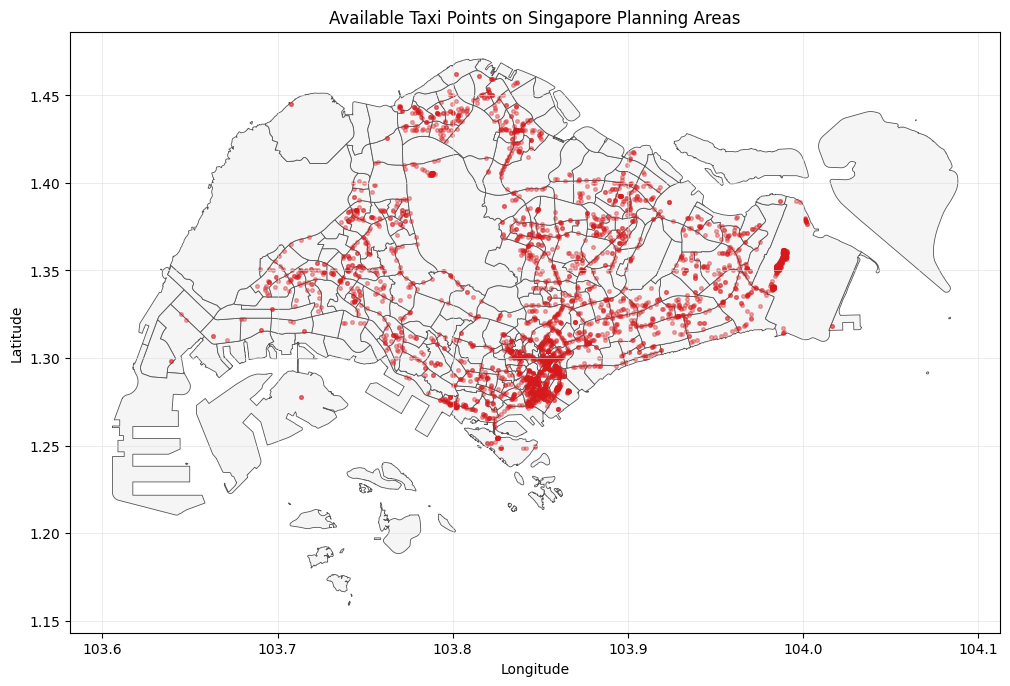

In [10]:
fig, ax = plt.subplots(figsize=(12, 12))

subzones_gdf.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#555555", linewidth=0.6)
taxis_joined_gdf.plot(ax=ax, color="#d7191c", markersize=7, alpha=0.35)

ax.set_title("Available Taxi Points on Singapore Planning Areas")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(True, color="#dddddd", linewidth=0.4)

plt.show()


## 7. Create DuckDB Tables for the Dashboard

Before creating tables, pause on the two structured CSV outputs that now look like database tables.

- `data/processed/taxi_counts_by_planning_area_latest.csv`: one row per taxi API snapshot and planning area, with `api_timestamp`, `planning_area`, and `available_taxi_count`.
- `data/processed/weather_forecasts_latest.csv`: one row per weather API update, forecast validity period, and area, with `api_update_timestamp`, `valid_period_start`, `valid_period_end`, `area`, and `forecast`.

These are the two base business tables. The database stores them so the dashboard and later SQL queries do not need to read loose CSV files directly.

`collection_runs` is a small pipeline log table. It records when the collection ran, whether it succeeded, and how many rows were inserted. This prepares us for scheduled workflows later.

In [8]:
def init_database(db_path: Path) -> None:
    with duckdb.connect(str(db_path)) as conn:
        conn.execute("""
            CREATE TABLE IF NOT EXISTS weather_forecasts (
                id BIGINT PRIMARY KEY,
                collection_time VARCHAR NOT NULL,
                api_update_timestamp VARCHAR NOT NULL,
                valid_period_start VARCHAR NOT NULL,
                valid_period_end VARCHAR NOT NULL,
                area VARCHAR NOT NULL,
                forecast VARCHAR NOT NULL,
                payload_hash VARCHAR NOT NULL,
                created_at VARCHAR NOT NULL DEFAULT CAST(CURRENT_TIMESTAMP AS VARCHAR),
                UNIQUE(api_update_timestamp, valid_period_start, valid_period_end, area)
            );

            CREATE TABLE IF NOT EXISTS taxi_availability (
                id BIGINT PRIMARY KEY,
                collection_time VARCHAR NOT NULL,
                api_timestamp VARCHAR NOT NULL,
                planning_area VARCHAR NOT NULL,
                available_taxi_count BIGINT NOT NULL,
                payload_hash VARCHAR NOT NULL,
                created_at VARCHAR NOT NULL DEFAULT CAST(CURRENT_TIMESTAMP AS VARCHAR),
                UNIQUE(api_timestamp, planning_area)
            );

            CREATE TABLE IF NOT EXISTS rainfall_readings (
                id BIGINT PRIMARY KEY,
                collection_time VARCHAR NOT NULL,
                reading_timestamp VARCHAR NOT NULL,
                station_id VARCHAR NOT NULL,
                station_name VARCHAR,
                latitude DOUBLE,
                longitude DOUBLE,
                rainfall_mm DOUBLE NOT NULL,
                payload_hash VARCHAR NOT NULL,
                created_at VARCHAR NOT NULL DEFAULT CAST(CURRENT_TIMESTAMP AS VARCHAR),
                UNIQUE(reading_timestamp, station_id)
            );

            CREATE TABLE IF NOT EXISTS collection_runs (
                id BIGINT PRIMARY KEY,
                source VARCHAR NOT NULL,
                scheduled_for VARCHAR NOT NULL,
                started_at VARCHAR NOT NULL,
                ended_at VARCHAR NOT NULL,
                status VARCHAR NOT NULL,
                records_inserted BIGINT NOT NULL DEFAULT 0,
                message VARCHAR,
                created_at VARCHAR NOT NULL DEFAULT CAST(CURRENT_TIMESTAMP AS VARCHAR)
            );

            CREATE INDEX IF NOT EXISTS idx_weather_area_time
                ON weather_forecasts(area, api_update_timestamp);
            CREATE INDEX IF NOT EXISTS idx_taxi_area_time
                ON taxi_availability(planning_area, api_timestamp);
            CREATE INDEX IF NOT EXISTS idx_rainfall_station_time
                ON rainfall_readings(station_id, reading_timestamp);

            CREATE OR REPLACE VIEW taxi_availability_typed AS
            SELECT
                id,
                CAST(collection_time AS TIMESTAMPTZ) AS collection_time,
                CAST(api_timestamp AS TIMESTAMPTZ) AS api_timestamp,
                planning_area,
                available_taxi_count,
                payload_hash,
                CAST(created_at AS TIMESTAMP) AS created_at
            FROM taxi_availability;

            CREATE OR REPLACE VIEW weather_forecasts_typed AS
            SELECT
                id,
                CAST(collection_time AS TIMESTAMPTZ) AS collection_time,
                CAST(api_update_timestamp AS TIMESTAMPTZ) AS api_update_timestamp,
                CAST(valid_period_start AS TIMESTAMPTZ) AS valid_period_start,
                CAST(valid_period_end AS TIMESTAMPTZ) AS valid_period_end,
                area,
                forecast,
                payload_hash,
                CAST(created_at AS TIMESTAMP) AS created_at
            FROM weather_forecasts;

            CREATE OR REPLACE VIEW rainfall_readings_typed AS
            SELECT
                id,
                CAST(collection_time AS TIMESTAMPTZ) AS collection_time,
                CAST(reading_timestamp AS TIMESTAMPTZ) AS reading_timestamp,
                station_id,
                station_name,
                latitude,
                longitude,
                rainfall_mm,
                payload_hash,
                CAST(created_at AS TIMESTAMP) AS created_at
            FROM rainfall_readings;
        """)


def next_id(conn: duckdb.DuckDBPyConnection, table_name: str) -> int:
    row = conn.execute(f"SELECT COALESCE(MAX(id), 0) + 1 FROM {table_name}").fetchone()
    if row is None:
        raise RuntimeError(f"Failed to calculate the next ID for {table_name}.")
    return int(row[0])


def count_rows(conn: duckdb.DuckDBPyConnection, table_name: str) -> int:
    row = conn.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()
    if row is None:
        raise RuntimeError(f"Failed to count rows in {table_name}.")
    return int(row[0])


## 8. Insert Processed Data

In [9]:
def insert_weather_forecasts(db_path: Path, collection_time: str, weather: pd.DataFrame, hash_value: str) -> int:
    with duckdb.connect(str(db_path)) as conn:
        start_id = next_id(conn, "weather_forecasts")
        before = count_rows(conn, "weather_forecasts")
        rows = [
            (
                start_id + index,
                collection_time,
                row.api_update_timestamp,
                row.valid_period_start,
                row.valid_period_end,
                row.area,
                row.forecast,
                hash_value,
            )
            for index, row in enumerate(weather.itertuples(index=False))
        ]
        conn.executemany(
            """
            INSERT OR IGNORE INTO weather_forecasts (
                id, collection_time, api_update_timestamp, valid_period_start,
                valid_period_end, area, forecast, payload_hash
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """,
            rows,
        )
        after = count_rows(conn, "weather_forecasts")
        return after - before


def insert_taxi_counts(db_path: Path, collection_time: str, api_timestamp: str, counts: pd.DataFrame, hash_value: str) -> int:
    with duckdb.connect(str(db_path)) as conn:
        start_id = next_id(conn, "taxi_availability")
        before = count_rows(conn, "taxi_availability")
        rows = [
            (start_id + index, collection_time, api_timestamp, row.planning_area, int(row.available_taxi_count), hash_value)
            for index, row in enumerate(counts.itertuples(index=False))
        ]
        conn.executemany(
            """
            INSERT OR IGNORE INTO taxi_availability (
                id, collection_time, api_timestamp, planning_area,
                available_taxi_count, payload_hash
            ) VALUES (?, ?, ?, ?, ?, ?)
            """,
            rows,
        )
        after = count_rows(conn, "taxi_availability")
        return after - before


def insert_rainfall_readings(db_path: Path, collection_time: str, readings: pd.DataFrame, hash_value: str) -> int:
    with duckdb.connect(str(db_path)) as conn:
        start_id = next_id(conn, "rainfall_readings")
        before = count_rows(conn, "rainfall_readings")
        rows = [
            (
                start_id + index,
                collection_time,
                row.reading_timestamp,
                row.station_id,
                row.station_name,
                row.latitude,
                row.longitude,
                float(row.rainfall_mm),
                hash_value,
            )
            for index, row in enumerate(readings.itertuples(index=False))
        ]
        conn.executemany(
            """
            INSERT OR IGNORE INTO rainfall_readings (
                id, collection_time, reading_timestamp, station_id, station_name,
                latitude, longitude, rainfall_mm, payload_hash
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
            """,
            rows,
        )
        after = count_rows(conn, "rainfall_readings")
        return after - before


def record_run(db_path: Path, source: str, scheduled_for: datetime, started_at: datetime, ended_at: datetime, status: str, records_inserted: int, message: str | None = None) -> None:
    with duckdb.connect(str(db_path)) as conn:
        conn.execute(
            """
            INSERT INTO collection_runs (
                id, source, scheduled_for, started_at, ended_at,
                status, records_inserted, message
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """,
            (next_id(conn, "collection_runs"), source, to_iso(scheduled_for), to_iso(started_at), to_iso(ended_at), status, records_inserted, message),
        )


In [10]:
init_database(DB_PATH)
collection_time = to_iso(collection_started_at)

weather_inserted = insert_weather_forecasts(DB_PATH, collection_time, weather_df, weather_hash)
taxi_inserted = insert_taxi_counts(DB_PATH, collection_time, taxi_api_timestamp, taxi_counts_df, taxi_hash)
rainfall_inserted = insert_rainfall_readings(DB_PATH, collection_time, rainfall_df, rainfall_hash)
record_run(
    DB_PATH,
    source="weather",
    scheduled_for=collection_started_at,
    started_at=collection_started_at,
    ended_at=now_sgt(),
    status="success",
    records_inserted=weather_inserted,
    message=f"Raw file: {weather_raw_path.name}",
)
record_run(
    DB_PATH,
    source="taxi",
    scheduled_for=collection_started_at,
    started_at=collection_started_at,
    ended_at=now_sgt(),
    status="success",
    records_inserted=taxi_inserted,
    message=f"Raw file: {taxi_raw_path.name}",
)
record_run(
    DB_PATH,
    source="rainfall",
    scheduled_for=collection_started_at,
    started_at=collection_started_at,
    ended_at=now_sgt(),
    status="success",
    records_inserted=rainfall_inserted,
    message=f"Raw file: {rainfall_raw_path.name}",
)

print(f"Database: {DB_PATH}")
print(f"Inserted weather rows: {weather_inserted}")
print(f"Inserted taxi rows: {taxi_inserted}")
print(f"Inserted rainfall rows: {rainfall_inserted}")


Database: d:\SIT OneDrive\OneDrive - Singapore Institute Of Technology\project_IMDA\teaching\slides\day_1\day_1_weather_taxi_data.duckdb
Inserted weather rows: 47
Inserted taxi rows: 51


## 9. Select From the Database

In [11]:
with duckdb.connect(str(DB_PATH)) as conn:
    table_counts = conn.execute("""
        SELECT 'weather_forecasts' AS table_name, COUNT(*) AS row_count FROM weather_forecasts
        UNION ALL
        SELECT 'taxi_availability', COUNT(*) FROM taxi_availability
        UNION ALL
        SELECT 'rainfall_readings', COUNT(*) FROM rainfall_readings
        UNION ALL
        SELECT 'collection_runs', COUNT(*) FROM collection_runs
        """).fetchdf()
    latest_taxi = conn.execute("""
        SELECT api_timestamp, planning_area, available_taxi_count
        FROM taxi_availability
        ORDER BY api_timestamp DESC, available_taxi_count DESC
        LIMIT 10
        """).fetchdf()
    latest_weather = conn.execute("""
        SELECT api_update_timestamp, area, forecast
        FROM weather_forecasts
        ORDER BY api_update_timestamp DESC, area
        LIMIT 10
        """).fetchdf()
    latest_rainfall = conn.execute("""
        SELECT reading_timestamp, station_id, station_name, rainfall_mm
        FROM rainfall_readings
        ORDER BY reading_timestamp DESC, rainfall_mm DESC
        LIMIT 10
        """).fetchdf()

display(table_counts)
display(latest_taxi)
display(latest_weather)
display(latest_rainfall)


,table_name,row_count
0,weather_forecasts,47
1,taxi_availability,51
2,collection_runs,2


,api_timestamp,planning_area,available_taxi_count
0,2026-05-28T11:22:17+08:00,CHANGI,427
1,2026-05-28T11:22:17+08:00,BUKIT MERAH,306
2,2026-05-28T11:22:17+08:00,TAMPINES,225
3,2026-05-28T11:22:17+08:00,GEYLANG,191
4,2026-05-28T11:22:17+08:00,KALLANG,181
5,2026-05-28T11:22:17+08:00,BEDOK,166
6,2026-05-28T11:22:17+08:00,QUEENSTOWN,145
7,2026-05-28T11:22:17+08:00,DOWNTOWN CORE,142
8,2026-05-28T11:22:17+08:00,WOODLANDS,107
9,2026-05-28T11:22:17+08:00,ROCHOR,103


,api_update_timestamp,area,forecast
0,2026-05-28T11:11:09+08:00,Ang Mo Kio,Cloudy
1,2026-05-28T11:11:09+08:00,Bedok,Cloudy
2,2026-05-28T11:11:09+08:00,Bishan,Cloudy
3,2026-05-28T11:11:09+08:00,Boon Lay,Cloudy
4,2026-05-28T11:11:09+08:00,Bukit Batok,Cloudy
5,2026-05-28T11:11:09+08:00,Bukit Merah,Cloudy
6,2026-05-28T11:11:09+08:00,Bukit Panjang,Cloudy
7,2026-05-28T11:11:09+08:00,Bukit Timah,Cloudy
8,2026-05-28T11:11:09+08:00,Central Water Catchment,Cloudy
9,2026-05-28T11:11:09+08:00,Changi,Cloudy


## 10. Join Tables and Create an Analytical View

Now that the two base tables are in DuckDB and we can `SELECT` from them, we can ask a more analytical question: what is the weather forecast and taxi availability for each area?

This is a join problem. The weather table has one row per area forecast. The taxi table has one row per planning area count. We create a common text key, join the two tables, save the result as a CSV, and then store the joined result as a third DuckDB table for the dashboard.

In [12]:
weather_for_merge = weather_df.copy()
weather_for_merge["planning_area_key"] = weather_for_merge["area"].str.strip().str.upper()

taxi_for_merge = taxi_counts_df.copy()
taxi_for_merge["planning_area_key"] = taxi_for_merge["planning_area"].str.strip().str.upper()

merged_df = weather_for_merge.merge(taxi_for_merge, on="planning_area_key", how="left")
merged_df["planning_area"] = merged_df["area"]
merged_df["available_taxi_count"] = merged_df["available_taxi_count"].fillna(0).astype(int)
merged_df = merged_df[
    [
        "api_update_timestamp",
        "valid_period_start",
        "valid_period_end",
        "area",
        "forecast",
        "planning_area",
        "available_taxi_count",
    ]
]

merged_path = PROCESSED_DIR / "weather_taxi_merged_latest.csv"
merged_df.to_csv(merged_path, index=False)

with duckdb.connect(str(DB_PATH)) as conn:
    conn.register("merged_df", merged_df)
    conn.execute("""
        CREATE OR REPLACE TABLE weather_taxi_merged AS
        SELECT * FROM merged_df
    """)
    conn.unregister("merged_df")
    merged_preview = conn.execute("""
        SELECT api_update_timestamp, area, forecast, planning_area, available_taxi_count
        FROM weather_taxi_merged
        ORDER BY available_taxi_count DESC, area
        LIMIT 10
        """).fetchdf()

print(f"Merged rows: {len(merged_df):,}")
print(f"Saved merged CSV: {merged_path}")
display(merged_preview)

Merged rows: 47
Saved merged CSV: d:\SIT OneDrive\OneDrive - Singapore Institute Of Technology\project_IMDA\teaching\slides\day_1\data\processed\weather_taxi_merged_latest.csv


,api_update_timestamp,area,forecast,planning_area,available_taxi_count
0,2026-05-28T11:11:09+08:00,Changi,Cloudy,Changi,427
1,2026-05-28T11:11:09+08:00,Bukit Merah,Cloudy,Bukit Merah,306
2,2026-05-28T11:11:09+08:00,Tampines,Cloudy,Tampines,225
3,2026-05-28T11:11:09+08:00,Geylang,Cloudy,Geylang,191
4,2026-05-28T11:11:09+08:00,Kallang,Cloudy,Kallang,181
5,2026-05-28T11:11:09+08:00,Bedok,Cloudy,Bedok,166
6,2026-05-28T11:11:09+08:00,Queenstown,Cloudy,Queenstown,145
7,2026-05-28T11:11:09+08:00,Woodlands,Cloudy,Woodlands,107
8,2026-05-28T11:11:09+08:00,Novena,Cloudy,Novena,93
9,2026-05-28T11:11:09+08:00,Yishun,Cloudy,Yishun,93


## 11. Scheduled Collection

A dashboard with only one API snapshot is not very useful. To see trends, we need multiple collection times. The notebook proves the logic once; the next step is to run the same logic repeatedly.

For this exercise, the runnable script is:

`scheduled_data_collector.py`

From a terminal in the `day_1_exercise` folder, first test one collection run:

```powershell
python scheduled_data_collector.py --run-once --source both --verbose
```

If your notebook uses the local virtual environment, run the venv Python explicitly:

```powershell
.\.venv\Scripts\python scheduled_data_collector.py --run-once --source both --verbose
```

To keep collecting data during class, leave this running in a terminal:

```powershell
python scheduled_data_collector.py --taxi-interval-minutes 10 --weather-interval-minutes 30 --rainfall-interval-minutes 5 --verbose
```

Stop it with `Ctrl+C` after you have enough snapshots for the dashboard.

A more operating-system style schedule is to run one collection every 10 minutes. On Windows Task Scheduler, the command is conceptually:

```powershell
schtasks /Create /TN "Day1WeatherTaxiCollector" /SC MINUTE /MO 10 /TR "python D:\path\to\day_1_exercise\scheduled_data_collector.py --run-once --source both" /F
```

On Linux or macOS cron, the equivalent idea is:

```bash
*/10 * * * * cd /path/to/day_1_exercise && python scheduled_data_collector.py --run-once --source both >> collector.log 2>&1
```

The important production ideas are the same as the notebook:

- each run fetches fresh taxi and weather data;
- uniqueness constraints prevent duplicate rows for the same API snapshot;
- `collection_runs` records whether the job succeeded;
- this prepares us for Day 2 workflow orchestration with Airflow.


## 12. Dashboard Handoff

From a terminal in this folder, run:

```bash
python -m uvicorn serving_api:app --reload --host 127.0.0.1 --port 8000
```

Then open `http://localhost:8000`.
